(1507, 5)
Price           Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267952  72.306521  70.568525  70.819223  118387200
2020-01-07  71.928062  72.533103  71.708703  72.277586  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200
<class 'pandas.DataFrame'>
DatetimeIndex: 1507 entries, 2020-01-02 to 2025-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1507 non-null   float64
 1   High    1507 non-null   float64
 2   Low     1507 non-null   float64
 3   Open    1507 non-null   float64
 4   Volume  1507 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 70.6 KB
None
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Price        Close  D

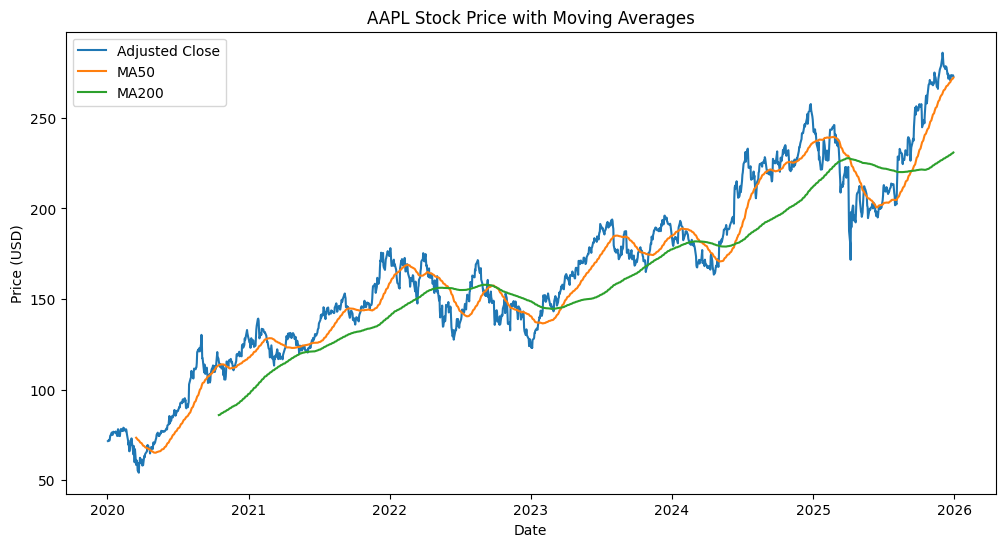

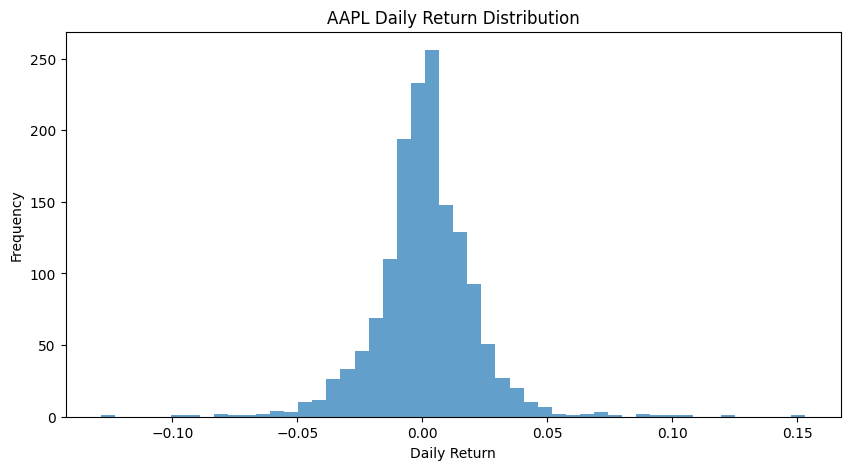

Mean Daily Return: 0.0011
Standard Deviation: 0.02
Max Daily Return: 0.1533
Min Daily Return: -0.1286


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

start_date = '2020-01-01'
end_date = '2025-12-31'
ticker = 'AAPL'
data = yf.download(ticker, start=start_date, end=end_date, progress=False)
data.columns = data.columns.droplevel(1)

print(data.shape)
print(data.head())
print(data.info())
print(data.isnull().sum())

data = data.dropna()
data['Daily_Return'] = data['Close'].pct_change()
data = data.dropna(subset=['Daily_Return'])

data['MA50'] = data['Close'].rolling(window=50).mean()
data['MA200'] = data['Close'].rolling(window=200).mean()

print(data[['Close', 'Daily_Return']].describe())

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Adjusted Close')
plt.plot(data['MA50'], label='MA50')
plt.plot(data['MA200'], label='MA200')
plt.title('AAPL Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.hist(data['Daily_Return'], bins=50, alpha=0.7)
plt.title('AAPL Daily Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

print("Mean Daily Return:", round(data['Daily_Return'].mean(), 4))
print("Standard Deviation:", round(data['Daily_Return'].std(), 4))
print("Max Daily Return:", round(data['Daily_Return'].max(), 4))
print("Min Daily Return:", round(data['Daily_Return'].min(), 4))